In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


## 1. Introduction and Setup
- Goal: Predict daily `audience_count` for BookNow theatres.
- BookNow = online booking platform; CinePOS = theatre-side POS system.
- Given multiple CSV files: visits, theatre info, mapping table, bookings, date_info.

### Problem Statement
- Use past audience data + theatre metadata + date features to forecast audience_count.
- Target variable: `audience_count`
- This is a **regression + time-series forecasting** problem.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')


## 2. Load Datasets

- Read all competition CSV files into pandas DataFrames.
- Each table stores theatre details, bookings, visits, or calendar information.
- Print the shape of each DataFrame to confirm successful loading.

In [3]:
cinepos_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
booknow_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
movie_theater_rel = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
cinepos_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
booknow_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')
# quick check: print shapes of all loaded tables
print("cinePOS_theaters:", cinepos_theaters.shape)
print("booknow_theaters:", booknow_theaters.shape)
print("movie_theater_id_relation:", movie_theater_rel.shape)
print("cinePOS_booking:", cinepos_booking.shape)
print("booknow_booking:", booknow_booking.shape)
print("booknow_visits:", booknow_visits.shape)
print("date_info:", date_info.shape)
print("sample_submission:", submission.shape)

cinePOS_theaters: (4690, 5)
booknow_theaters: (829, 5)
movie_theater_id_relation: (150, 2)
cinePOS_booking: (1641966, 4)
booknow_booking: (68336, 4)
booknow_visits: (214046, 3)
date_info: (547, 2)
sample_submission: (38062, 2)


In [4]:
cinepos_theaters.head(2)

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619,78.113
1,cinePOS_08708,Other,Area_104,22.619,78.113


In [5]:
booknow_theaters.head(2)

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619,78.113
1,book_00078,Drama,Area_001,22.619,78.113


In [6]:
movie_theater_rel.head(2)

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467


In [7]:
cinepos_booking.head(2)

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3


In [8]:
booknow_booking.head(2)

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3


In [9]:
booknow_visits.head(2)

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64


In [10]:
date_info.head(2)

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday


## 3. Exploratory Data Analysis(EDA)
3.1 Check Column Types, Missing Values, Basic Stats

In [11]:
print("booknow_visits info:")
print(booknow_visits.info())

print("\nMissing values in booknow_visits:")
print(booknow_visits.isnull().sum())

print("\nSummary statistics for audience_count:")
print(booknow_visits['audience_count'].describe())

booknow_visits info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB
None

Missing values in booknow_visits:
book_theater_id    0
show_date          0
audience_count     0
dtype: int64

Summary statistics for audience_count:
count   214046.000
mean        41.617
std         32.835
min          2.000
25%         18.000
50%         34.000
75%         58.000
max       1350.000
Name: audience_count, dtype: float64


 The dataset contains **214,046 rows** and **3 columns**, representing visits for different theatres and dates.
- There are **no missing values** in any column, so the dataset is already clean.
- `book_theater_id` and `show_date` are stored as object types and will be converted later.
- The target variable `audience_count` ranges from **2 to 1350**.
- The distribution is **right-skewed**:
  - 50% of shows have fewer than **34** people.
  - 75% have fewer than **58**.
  - A small number of shows reach very high audience counts (max = **1350**), indicating outliers.
- The standard deviation (**32.8**) is close to the mean (**41.6**), indicating large variability.

3.2 Convert date columns to datetime

In [12]:
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
cinepos_booking['show_datetime'] = pd.to_datetime(cinepos_booking['show_datetime'])
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])

Machine learning models and feature engineering techniques cannot work effectively with string dates, so the first step was to convert them into Python datetime objects using pd.to_datetime().”

3.3 Audience Count Distribution

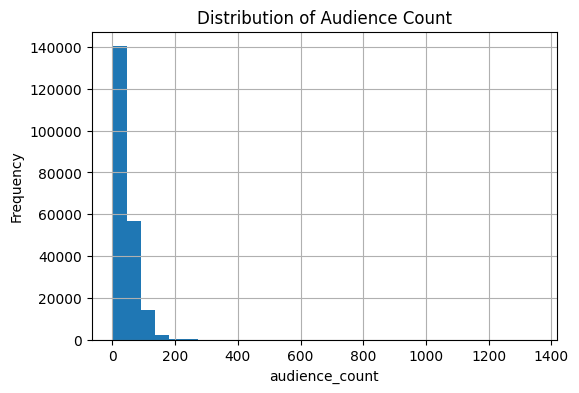

In [13]:
plt.figure(figsize=(6,4))
booknow_visits["audience_count"].hist(bins=30)
plt.title("Distribution of Audience Count")
plt.xlabel("audience_count")
plt.ylabel("Frequency")
plt.show()

- The distribution is **heavily right-skewed**.
- Most shows have an audience count between **0 and 150**.
- Very few shows exceed **400+**, and extremely rare cases reach **1000–1350**.
- This confirms strong **outliers** and **high variance** in the target.

3.4 Audience Count Over Time

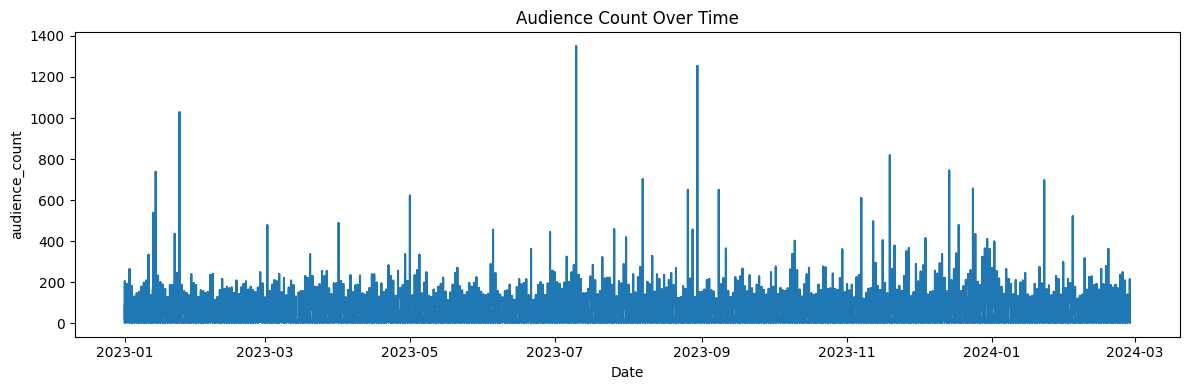

In [14]:
visits_ts = booknow_visits.copy()
visits_ts["show_date"] = pd.to_datetime(visits_ts["show_date"])
visits_ts = visits_ts.sort_values("show_date")

plt.figure(figsize=(12,4))
plt.plot(visits_ts["show_date"], visits_ts["audience_count"])
plt.title("Audience Count Over Time")
plt.xlabel("Date")
plt.ylabel("audience_count")
plt.tight_layout()
plt.show()

- The time-series is highly noisy with irregular spikes.
- Occasional extreme peaks (800–1300 range) occur during certain weeks/months.
- No clear long-term upward or downward trend is visible.
- Indicates that the data has **event-driven spikes**, making lag features important.

3.5 Average Audience by Day of Week

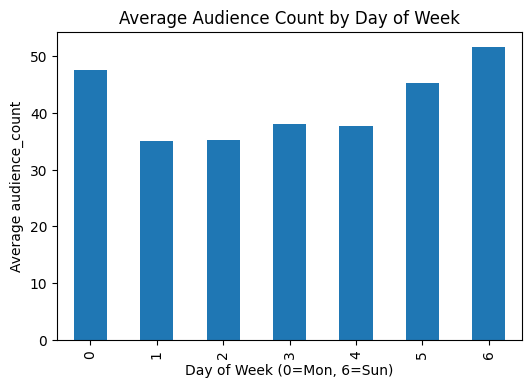

In [15]:
visits_dow = booknow_visits.copy()
visits_dow["show_date"] = pd.to_datetime(visits_dow["show_date"])
visits_dow["dayofweek"] = visits_dow["show_date"].dt.dayofweek   # 0=Mon, 6=Sun

avg_dow = visits_dow.groupby("dayofweek")["audience_count"].mean()

plt.figure(figsize=(6,4))
avg_dow.plot(kind="bar")
plt.title("Average Audience Count by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Average audience_count")
plt.show()

- Audience is **highest on Sundays (day 6)**.
- Monday (day 0) also has a relatively high average.
- Lowest audience counts occur mid-week (Tuesday–Thursday).
- Confirms weekly seasonality → `day_of_week` is an important predictive feature.
- This confirms strong weekly seasonality, and it shows that day_of_week is an important feature for our model

3.6 Monthly Audience Distribution (Boxplot)

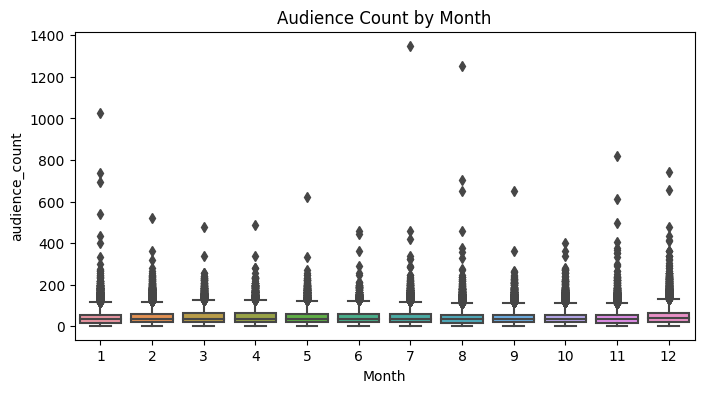

In [16]:
visits_month = booknow_visits.copy()
visits_month["show_date"] = pd.to_datetime(visits_month["show_date"])
visits_month["month"] = visits_month["show_date"].dt.month

plt.figure(figsize=(8,4))
sns.boxplot(x="month", y="audience_count", data=visits_month)
plt.title("Audience Count by Month")
plt.xlabel("Month")
plt.ylabel("audience_count")
plt.show()

- All months show significant outliers (400–1300 range).
- Median audience levels remain relatively stable across months.
- Slight peaks in mid-year months (Jun–Aug), but no extreme seasonal pattern.
- The presence of outliers again confirms high variability.
- Overall, the plot confirms high variability and no strong monthly seasonal pattern, but the presence of outliers is consistent

## 4. Dataset Preparation and Merging

In [17]:
# Merge visits with date_info to add day_of_week
train_df = booknow_visits.merge(date_info, on="show_date", how="left")

# Merge with booknow_theaters to add theatre metadata
train_df = train_df.merge(booknow_theaters,on="book_theater_id", how="left")

# Sort by theatre and date
train_df = train_df.sort_values(by=["book_theater_id", "show_date"]).reset_index(drop=True)

print("Train dataframe shape:", train_df.shape)

Train dataframe shape: (214046, 8)


- merged all the required datasets to create one complete training dataframe.
- joined the visit data with date_info to add day-of-week information.
- merged theatre metadata like theatre type, area, latitude and longitude to add location-based features.
- used a left join to ensure no audience records are lost.
- sorted the dataframe by theatre ID and show date to prepare it for time-series feature engineering like lag values.

In [18]:
print("\nTrain dataframe info:")
print(train_df.info())


Train dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
 3   day_of_week      214046 non-null  object        
 4   theater_type     80150 non-null   object        
 5   theater_area     80150 non-null   object        
 6   latitude         80150 non-null   float64       
 7   longitude        80150 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 13.1+ MB
None


## 5. Missing Values Detection and Basic Cleaning

- After merging multiple datasets, some theatre-related columns may contain missing values.
- It is important to identify which fields require imputation before modelling.
- Here, I check missing values and fill theatre-level attributes with simple, interpretable defaults.

In [19]:
print("\nMissing values in train_df:")
print(train_df.isnull().sum())

train_df["theater_type"] = train_df["theater_type"].fillna("Unknown")
train_df["theater_area"] = train_df["theater_area"].fillna("Unknown")

lat_median = train_df["latitude"].median()
lon_median = train_df["longitude"].median()

train_df["latitude"]  = train_df["latitude"].fillna(lat_median)
train_df["longitude"] = train_df["longitude"].fillna(lon_median)

print("\nAfter filling missing values:")
print(train_df.isnull().sum())


Missing values in train_df:
book_theater_id         0
show_date               0
audience_count          0
day_of_week             0
theater_type       133896
theater_area       133896
latitude           133896
longitude          133896
dtype: int64

After filling missing values:
book_theater_id    0
show_date          0
audience_count     0
day_of_week        0
theater_type       0
theater_area       0
latitude           0
longitude          0
dtype: int64


- A large number of missing values were found in theatre-level metadata:
  - `theater_type`, `theater_area`, `latitude`, `longitude`.
- These missing values occur because not all BookNow theatres have corresponding CinePOS information.
- Categorical features were filled with `"Unknown"` so models can treat them as a separate category.
- Numeric location features were imputed using the **median**, which is robust to outliers.
- After imputation, the dataset has **no missing values**, making it ready for preprocessing and modelling.

In [20]:
train_df.head()

,book_theater_id,show_date,audience_count,day_of_week,theater_type,theater_area,latitude,longitude
0,book_00001,2023-01-13,50,Friday,Drama,Area_002,23.004,79.935
1,book_00001,2023-01-14,64,Saturday,Drama,Area_002,23.004,79.935
2,book_00001,2023-01-15,58,Sunday,Drama,Area_002,23.004,79.935
3,book_00001,2023-01-16,44,Monday,Drama,Area_002,23.004,79.935
4,book_00001,2023-01-18,12,Wednesday,Drama,Area_002,23.004,79.935


## 6. Feature Engineering

5.1 Create Date-Based Numeric Features

In [21]:
# Date + Calendar Features for train_df 

# Basic date parts
train_df["day"]          = train_df["show_date"].dt.day
train_df["month"]        = train_df["show_date"].dt.month
train_df["year"]         = train_df["show_date"].dt.year
train_df["day_of_year"]  = train_df["show_date"].dt.dayofyear
train_df["week_of_year"] = train_df["show_date"].dt.isocalendar().week.astype(int)
train_df["quarter"]      = train_df["show_date"].dt.quarter
train_df["day_of_week"]  = train_df["show_date"].dt.day_name()
train_df["is_month_start"] = (train_df["day"] <= 3).astype(int)
train_df["is_month_end"]   = (train_df["day"] >= 28).astype(int)
train_df["is_festive_month"] = train_df["month"].isin([10, 11, 12]).astype(int)
# Season feature
def map_season(m):
    if m in [3, 4, 5]:
        return "Summer"       # exam/holiday season
    elif m in [6, 7, 8, 9]:
        return "Monsoon"      # rainy months
    else:  # 10,11,12,1,2
        return "Winter"

train_df["season"] = train_df["month"].apply(map_season)
# Weekend flag (Sat/Sun)
train_df["is_weekend"] = train_df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Simple holiday proxy: treat weekends as holidays
train_df["is_holiday"] = train_df["is_weekend"]

# Movie Release Day Spike (Friday)
train_df["is_friday_release"] = (train_df["day_of_week"] == "Friday").astype(int)
print(train_df.head())
# Cyclical encoding for day-of-year
train_df["day_sin"] = np.sin(2 * np.pi * train_df["day_of_year"] / 365)
train_df["day_cos"] = np.cos(2 * np.pi * train_df["day_of_year"] / 365)


  book_theater_id  show_date  audience_count day_of_week theater_type  \
0      book_00001 2023-01-13              50      Friday        Drama   
1      book_00001 2023-01-14              64    Saturday        Drama   
2      book_00001 2023-01-15              58      Sunday        Drama   
3      book_00001 2023-01-16              44      Monday        Drama   
4      book_00001 2023-01-18              12   Wednesday        Drama   

  theater_area  latitude  longitude  day  month  year  day_of_year  \
0     Area_002    23.004     79.935   13      1  2023           13   
1     Area_002    23.004     79.935   14      1  2023           14   
2     Area_002    23.004     79.935   15      1  2023           15   
3     Area_002    23.004     79.935   16      1  2023           16   
4     Area_002    23.004     79.935   18      1  2023           18   

   week_of_year  quarter  is_month_start  is_month_end  is_festive_month  \
0             2        1               0             0          

- Extracted calendar-based features from `show_date`: day, month, year, day_of_year, week_of_year, quarter.
- Added `is_month_start` and `is_month_end` to capture monthly effects.
- Created custom `season` feature (Summer / Monsoon / Winter).
- Added weekend & holiday indicators (`is_weekend`, `is_holiday`) for weekly seasonality.
- Added `is_friday_release` because movies usually release on Fridays → first-day spikes.
- Used cyclical encoding (`day_sin`, `day_cos`) so models understand yearly cycles.
- Goal: help model learn time patterns → seasonality, holidays, release trends.

In [22]:
# Theatre-level statistics 
stats = train_df.groupby("book_theater_id")["audience_count"]

theatre_median = stats.median()
theatre_total  = stats.sum()

train_df["theatre_baseline"] = train_df["book_theater_id"].map(theatre_median)
train_df["theatre_total"]    = train_df["book_theater_id"].map(theatre_total)

print(train_df[["book_theater_id", "theatre_baseline", "theatre_total"]].head())

  book_theater_id  theatre_baseline  theatre_total
0      book_00001            46.000          16094
1      book_00001            46.000          16094
2      book_00001            46.000          16094
3      book_00001            46.000          16094
4      book_00001            46.000          16094


- Grouped data by `book_theater_id` to capture theatre-specific behaviour.
- `theatre_baseline` → median audience for each theatre (stable, ignores spikes).
- `theatre_total` → total audience accumulated (identifies big vs small theatres).
- Helps model understand natural performance level of each theatre.
- Adds important context → same show can perform differently in different theatres.

5.2 Define Feature Columns + Target

In [23]:
target = "audience_count"

num_cols = ["day", "month", "year", "day_of_year", "week_of_year", "quarter"]
cat_cols = ["book_theater_id", "day_of_week"]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['day', 'month', 'year', 'day_of_year', 'week_of_year', 'quarter']
Categorical columns: ['book_theater_id', 'day_of_week']


## 7. Building Preprocessing Pipeline

In [24]:

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Categorical groups
cat_id_cols = ["book_theater_id"]                       
cat_other_cols = ["day_of_week", "theater_type", "theater_area"]  
preprocessor_all = ColumnTransformer(
    transformers=[
        ("encode_id",
         OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
         cat_id_cols),

        ("encode_other_cats",
         OneHotEncoder(handle_unknown="ignore"),
         cat_other_cols),
    ],
    remainder="passthrough"   
)


- Built a unified pipeline to avoid data leakage and ensure consistent preprocessing.
- Used `ColumnTransformer` to apply different encodings to different categorical groups.
- `book_theater_id` → OrdinalEncoder (many unique values, efficient).
- Used `unknown_value=-1` so unseen theatres do not break the model.
- `day_of_week`, `theater_type`, `theater_area` → OneHotEncoder (few categories, no order).
- `handle_unknown="ignore"` prevents errors for unseen categories.
- `remainder="passthrough"` keeps all numeric features untouched.
- Ensures stable and reproducible preprocessing for both train and test.

In [25]:
train_df.head()

,book_theater_id,show_date,audience_count,day_of_week,theater_type,theater_area,latitude,longitude,day,month,year,day_of_year,week_of_year,quarter,is_month_start,is_month_end,is_festive_month,season,is_weekend,is_holiday,is_friday_release,day_sin,day_cos,theatre_baseline,theatre_total
0,book_00001,2023-01-13,50,Friday,Drama,Area_002,23.004,79.935,13,1,2023,13,2,1,0,0,0,Winter,0,0,1,0.222,0.975,46.000,16094
1,book_00001,2023-01-14,64,Saturday,Drama,Area_002,23.004,79.935,14,1,2023,14,2,1,0,0,0,Winter,1,1,0,0.239,0.971,46.000,16094
2,book_00001,2023-01-15,58,Sunday,Drama,Area_002,23.004,79.935,15,1,2023,15,2,1,0,0,0,Winter,1,1,0,0.255,0.967,46.000,16094
3,book_00001,2023-01-16,44,Monday,Drama,Area_002,23.004,79.935,16,1,2023,16,3,1,0,0,0,Winter,0,0,0,0.272,0.962,46.000,16094
4,book_00001,2023-01-18,12,Wednesday,Drama,Area_002,23.004,79.935,18,1,2023,18,3,1,0,0,0,Winter,0,0,0,0.305,0.952,46.000,16094


## 8. Lag Features & Rolling Features (Time Series Engineering)

To model audience_count accurately, the model must understand how today’s behaviour is influenced by recent past trends.
Lag features and rolling averages help the model capture these time-dependent patterns.

In [26]:
# Group by theatre for time-series processing
group = train_df.groupby("book_theater_id")

# Create lag features
for l in [1, 2, 3, 7,14,21,30,60,90]:
    train_df[f"lag_{l}"] = group["audience_count"].shift(l)

Lag features represent the audience count on previous days.
They help the model learn patterns such as:
- Yesterday’s audience → immediate trend
- Last week’s audience (lag_7) → weekly seasonality
- Last month (lag_30) or quarter (lag_90) → long-term trends
Lags tell the model how the theatre has been performing right before the prediction day

In [27]:
# Rolling mean features
train_df["rolling_mean_3"]  = group["audience_count"].shift(1).rolling(window=3,  min_periods=1).mean()
train_df["rolling_mean_7"]  = group["audience_count"].shift(1).rolling(window=7,  min_periods=1).mean()
train_df["rolling_mean_14"] = group["audience_count"].shift(1).rolling(window=14, min_periods=1).mean()
train_df["rolling_mean_21"] = group["audience_count"].shift(1).rolling(window=21, min_periods=1).mean()
train_df["rolling_mean_30"] = group["audience_count"].shift(1).rolling(window=30, min_periods=1).mean()
train_df["rolling_mean_60"] = group["audience_count"].shift(1).rolling(window=60, min_periods=1).mean()
train_df["rolling_mean_90"] = group["audience_count"].shift(1).rolling(window=90, min_periods=1).mean()

train_df[[
    "book_theater_id", "show_date", "audience_count","lag_1", "lag_2", "lag_3", "lag_7", "lag_14","lag_21","lag_30",
    "lag_60","lag_90","rolling_mean_3", "rolling_mean_7", "rolling_mean_14","rolling_mean_21","rolling_mean_30","rolling_mean_60","rolling_mean_90"
]].head(10)

,book_theater_id,show_date,audience_count,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_30,lag_60,lag_90,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_mean_21,rolling_mean_30,rolling_mean_60,rolling_mean_90
0,book_00001,2023-01-13,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,book_00001,2023-01-14,64,50.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000,50.000,50.000,50.000,50.000,50.000,50.000
2,book_00001,2023-01-15,58,64.000,50.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.000,57.000,57.000,57.000,57.000,57.000,57.000
3,book_00001,2023-01-16,44,58.000,64.000,50.000,NaN,NaN,NaN,NaN,NaN,NaN,57.333,57.333,57.333,57.333,57.333,57.333,57.333
4,book_00001,2023-01-18,12,44.000,58.000,64.000,NaN,NaN,NaN,NaN,NaN,NaN,55.333,54.000,54.000,54.000,54.000,54.000,54.000
5,book_00001,2023-01-19,18,12.000,44.000,58.000,NaN,NaN,NaN,NaN,NaN,NaN,38.000,45.600,45.600,45.600,45.600,45.600,45.600
6,book_00001,2023-01-20,62,18.000,12.000,44.000,NaN,NaN,NaN,NaN,NaN,NaN,24.667,41.000,41.000,41.000,41.000,41.000,41.000
7,book_00001,2023-01-21,42,62.000,18.000,12.000,50.000,NaN,NaN,NaN,NaN,NaN,30.667,44.000,44.000,44.000,44.000,44.000,44.000
8,book_00001,2023-01-22,36,42.000,62.000,18.000,64.000,NaN,NaN,NaN,NaN,NaN,40.667,42.857,43.750,43.750,43.750,43.750,43.750
9,book_00001,2023-01-23,52,36.000,42.000,62.000,58.000,NaN,NaN,NaN,NaN,NaN,46.667,38.857,42.889,42.889,42.889,42.889,42.889


Rolling averages smooth out daily noise and highlight overall trends.
They capture:
- Short-term trend (3-day mean)
- Weekly trend (7-day mean)
- Monthly stability (30-day mean)
- Long-term theatre behaviour (90-day mean)
These features help the model understand stability vs. volatility in audience patterns.

In [28]:
# Impute missing lag/rolling values in TRAIN (train_df)
lag_columns = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14","lag_21","lag_30","lag_60","lag_90",
    "rolling_mean_3", "rolling_mean_7", "rolling_mean_14","rolling_mean_21",
    "rolling_mean_30","rolling_mean_60","rolling_mean_90"
]
for col in lag_columns:
    train_df[col] = train_df.groupby("book_theater_id")[col].transform(
        lambda x: x.fillna(x.mean())
    )

- Lag and rolling features contain NaN for first few days of each theatre.
- These NaNs come from lack of historical data (e.g., first day has no lag_1).
- fill missing values **within each theatre**, not globally.
- Used: groupby('book_theater_id') + fillna(mean)
- Ensures:
  - No cross-theatre leakage
  - Smooth, consistent historical patterns
  - Model receives complete data without breaking time-series logic

In [29]:
num_cols = [
    "day", "month", "year","day_of_year", "week_of_year", "quarter","is_weekend","is_holiday","is_friday_release",
    "is_month_start","is_month_end","is_festive_month","day_sin","day_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14","lag_21","lag_30",
    "lag_60","lag_90","rolling_mean_3", "rolling_mean_7", "rolling_mean_14","rolling_mean_21",
    "rolling_mean_30","rolling_mean_60","rolling_mean_90","latitude", "longitude"
]

cat_cols = [
    "book_theater_id",
    "day_of_week",
    "season",        
    "theater_type",
    "theater_area"
]


In [30]:
feature_cols = num_cols + cat_cols

print("NaNs per feature BEFORE final clean:")
print(train_df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

# fill NaNs with column MEDIAN
num_all = train_df[feature_cols].select_dtypes(include=[np.number]).columns
for col in num_all:
    med = train_df[col].median()
    train_df[col] = train_df[col].fillna(med)

#  fill NaNs with "Unknown"
cat_all = train_df[feature_cols].select_dtypes(exclude=[np.number]).columns
for col in cat_all:
    train_df[col] = train_df[col].fillna("Unknown")

print("\nNaNs per feature AFTER final clean:")
print(train_df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

NaNs per feature BEFORE final clean:
lag_90             804
lag_60             363
lag_30             144
lag_21              37
lag_7                3
lag_3                3
lag_2                3
lag_14               3
lag_1                1
rolling_mean_90      0
rolling_mean_60      0
rolling_mean_30      0
latitude             0
rolling_mean_14      0
rolling_mean_7       0
longitude            0
book_theater_id      0
day_of_week          0
rolling_mean_3       0
season               0
dtype: int64

NaNs per feature AFTER final clean:
day                0
lag_21             0
lag_60             0
lag_90             0
rolling_mean_3     0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_21    0
rolling_mean_30    0
rolling_mean_60    0
rolling_mean_90    0
latitude           0
longitude          0
book_theater_id    0
day_of_week        0
season             0
theater_type       0
lag_30             0
lag_14             0
month              0
dtype: int64


## 9. Train–Validation Split

In [31]:
# TRAIN / VALIDATION SPLIT 

target = "audience_count"
feature_cols = num_cols + cat_cols   # from earlier sections

# sort by theatre + date for time-series
df = train_df.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)
print("Overall date range:",df["show_date"].min(), "to", df["show_date"].max())
split_date = df["show_date"].quantile(0.8)
print("Split date (80% point):", split_date)

# Boolean masks
train_mask = df["show_date"] < split_date
valid_mask = df["show_date"] >= split_date

# Final train/valid feature matrices
X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target]

X_valid = df.loc[valid_mask, feature_cols]
y_valid = df.loc[valid_mask, target]

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

print("\nTrain date range:",
      df.loc[train_mask, "show_date"].min(), "to",
      df.loc[train_mask, "show_date"].max())
print("Valid date range:",
      df.loc[valid_mask, "show_date"].min(), "to",
      df.loc[valid_mask, "show_date"].max())


Overall date range: 2023-01-01 00:00:00 to 2024-02-28 00:00:00
Split date (80% point): 2023-12-26 00:00:00
X_train shape: (170848, 37)
X_valid shape: (43198, 37)
y_train shape: (170848,)
y_valid shape: (43198,)

Train date range: 2023-01-01 00:00:00 to 2023-12-25 00:00:00
Valid date range: 2023-12-26 00:00:00 to 2024-02-28 00:00:00


## 10. Model Building

In [32]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("scale_num", StandardScaler(), num_cols),
        (
            "encode_theatre",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            ["book_theater_id"],
        ),
        (
            "encode_weekday",
            OneHotEncoder(handle_unknown="ignore"),
            ["day_of_week"],
        ),
    ]
)

### Linear Regression (Baseline model)

In [33]:
# Create pipeline
model_lr = Pipeline(steps=[
    ("preprocess", preprocessor_lr),
    ("model", LinearRegression())
])

# Fit on training data
model_lr.fit(X_train, y_train)

# Predict on validation data
y_pred_lr = model_lr.predict(X_valid)

# Evaluate
lr_r2 = r2_score(y_valid, y_pred_lr)
print("Linear Regression R² Score:", lr_r2)

Linear Regression R² Score: 0.4930943636074504


In [34]:
# Preprocessing

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Categorical groups
cat_id_cols = ["book_theater_id"]                       
cat_other_cols = ["day_of_week","season","theater_type", "theater_area"] 

preprocessor_all = ColumnTransformer(
    transformers=[
        ("encode_id",
         OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
         cat_id_cols),

        ("encode_other_cats",
         OneHotEncoder(handle_unknown="ignore"),
         cat_other_cols),
    ],
    remainder="passthrough"   
)


- I separated categorical columns into two groups:
   - High-cardinality → book_theater_id
   - Low-cardinality → day_of_week, season, theater_type, theater_area
- For theatre ID, I used OrdinalEncoder
   - because too many unique IDs, one-hot would explode dimensions.
- Set handle_unknown="use_encoded_value", unknown_value = -1
   - safely encodes unseen theatre IDs.
- For other categorical columns, I used OneHotEncoder
   - works best for small category sets.

### Random Forest Model

In [35]:
# Random forest
model_rf = Pipeline(steps=[
    ("preprocess", preprocessor_all),
    ("model", RandomForestRegressor(
        n_estimators=300,      
        max_depth=12,         
        min_samples_split=10, 
        random_state=42,
        n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_valid)

rf_r2 = r2_score(y_valid, y_pred_rf)
print("Random Forest R² Score:", rf_r2)

Random Forest R² Score: 0.4923368561653574


### GradientBoosting Model

In [36]:
# GradientBoosting
model_gb = Pipeline(steps=[
    ("preprocess", preprocessor_all),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
model_gb.fit(X_train, y_train)

# Predict
y_pred_gb = model_gb.predict(X_valid)

# R² score
gb_r2 = r2_score(y_valid, y_pred_gb)
print("Gradient Boosting R² Score:", gb_r2)

Gradient Boosting R² Score: 0.48599126778323143


### LightGBM Model

In [37]:
# LightGBM 
model_lgbm = Pipeline(steps=[
    ("preprocess", preprocessor_all),
    ("model", LGBMRegressor(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        force_row_wise=True
    ))
])

# Train
model_lgbm.fit(X_train, y_train)

# Predict
y_pred_lgbm = model_lgbm.predict(X_valid)

# R² score
lgbm_r2 = r2_score(y_valid, y_pred_lgbm)
print("LightGBM R² Score:", lgbm_r2)

LightGBM R² Score: 0.486866338272096


### XGBRegressor Model

In [38]:
# XGBRegressor
model_xgb = Pipeline(steps=[
    ("preprocess", preprocessor_all),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

# Train
model_xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = model_xgb.predict(X_valid)

# R² score
xgb_r2 = r2_score(y_valid, y_pred_xgb)
print("XGBRegressor R² Score:", xgb_r2)

XGBRegressor R² Score: 0.4793561605660486


In [39]:
# Model comparison
print("\nModel comparison (R²):")
print(f"RandomForest       : {rf_r2:.4f}")
print(f"GradientBoosting   : {gb_r2:.4f}")
print(f"XGBRegressor       : {xgb_r2:.4f}")
print(f"LightGBM           : {lgbm_r2:.4f}")


Model comparison (R²):
RandomForest       : 0.4923
GradientBoosting   : 0.4860
XGBRegressor       : 0.4794
LightGBM           : 0.4869


## 11. Hyperparameter tuning

In [40]:
from sklearn.model_selection import RandomizedSearchCV

# Pipeline to tune
lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor_all),
    ("model", LGBMRegressor(random_state=42,verbose=-1))
])

param_dist = {
    "model__n_estimators":   [300, 500, 700],
    "model__learning_rate":  [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves":     [31, 63, 127],
    "model__max_depth":      [-1, 5, 7, 9],
    "model__subsample":      [0.7, 0.85, 1.0],
    "model__colsample_bytree":[0.7, 0.85, 1.0],
    "model__min_child_samples": [20, 50, 100]
}

search = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=param_dist,
    n_iter=15,              
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

best_lgbm = search.best_estimator_
y_pred_tuned = best_lgbm.predict(X_valid)
print("Tuned LightGBM R² on validation:", r2_score(y_valid, y_pred_tuned))


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__subsample': 1.0, 'model__num_leaves': 31, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.85}
Best CV R²: 0.49735921003217864
Tuned LightGBM R² on validation: 0.5023532167600683


## 12. Test Set Preparation

In [41]:
import numpy as np
sample = submission.copy()

# Split ID & Build test_df
sample["book_theater_id"] = sample["ID"].str.rsplit("_", n=1).str[0]
sample["show_date"] = pd.to_datetime(sample["ID"].str.rsplit("_", n=1).str[1])

# Build test set
test_df = sample[["book_theater_id", "show_date"]].copy()
test_df["audience_count"] = np.nan

# Merge theatre metadata 
test_df = test_df.merge(booknow_theaters,on="book_theater_id",how="left")

In [42]:
# Fill missing categories
test_df["theater_type"]  = test_df["theater_type"].fillna("Unknown")
test_df["theater_area"]  = test_df["theater_area"].fillna("Unknown")
test_df["latitude"]   = test_df["latitude"].fillna(lat_median)
test_df["longitude"]  = test_df["longitude"].fillna(lon_median)

In [43]:
# Combine TRAIN + TEST
combined = pd.concat([train_df, test_df], ignore_index=True)
combined = combined.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)

In [44]:
# Date Features
combined["day"]          = combined["show_date"].dt.day
combined["month"]        = combined["show_date"].dt.month
combined["year"]         = combined["show_date"].dt.year
combined["day_of_year"]  = combined["show_date"].dt.dayofyear
combined["week_of_year"] = combined["show_date"].dt.isocalendar().week.astype(int)
combined["quarter"]      = combined["show_date"].dt.quarter
combined["day_of_week"]  = combined["show_date"].dt.day_name()
combined["is_month_start"]   = (combined["day"] <= 3).astype(int)
combined["is_month_end"]     = (combined["day"] >= 28).astype(int)
combined["is_festive_month"] = combined["month"].isin([10, 11, 12]).astype(int)

In [45]:
# Season
combined["season"] = combined["month"].apply(map_season)

# Weekend & holiday proxy
combined["is_weekend"] = combined["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
combined["is_holiday"] = combined["is_weekend"]

# Friday release spike
combined["is_friday_release"] = (combined["day_of_week"] == "Friday").astype(int)

In [46]:
# Cyclical encoding for day_of_year
combined["day_sin"] = np.sin(2 * np.pi * combined["day_of_year"] / 365)
combined["day_cos"] = np.cos(2 * np.pi * combined["day_of_year"] / 365)
# Theatre-level statistics (use ONLY train rows to compute stats)
train_part = combined[combined["audience_count"].notna()]
stats = train_part.groupby("book_theater_id")["audience_count"]
theatre_median = stats.median()
theatre_total  = stats.sum()

In [47]:
combined["theatre_baseline"] = combined["book_theater_id"].map(theatre_median)
combined["theatre_total"]    = combined["book_theater_id"].map(theatre_total)

In [48]:
# Recompute Lag & Rolling features
group = combined.groupby("book_theater_id")

# Lag features
for l in [1, 2, 3, 7, 14,21,30,60,90]:
    combined[f"lag_{l}"] = group["audience_count"].shift(l)

# Rolling means
combined["rolling_mean_3"]  = group["audience_count"].shift(1).rolling(3,  min_periods=1).mean()
combined["rolling_mean_7"]  = group["audience_count"].shift(1).rolling(7,  min_periods=1).mean()
combined["rolling_mean_14"] = group["audience_count"].shift(1).rolling(14, min_periods=1).mean()
combined["rolling_mean_21"] = group["audience_count"].shift(1).rolling(21, min_periods=1).mean()
combined["rolling_mean_30"] = group["audience_count"].shift(1).rolling(30, min_periods=1).mean()
combined["rolling_mean_60"] = group["audience_count"].shift(1).rolling(60, min_periods=1).mean()
combined["rolling_mean_90"] = group["audience_count"].shift(1).rolling(90, min_periods=1).mean()

In [49]:
# Split back into TRAIN + TEST
train_final = combined[combined["audience_count"].notna()].copy()
test_final  = combined[combined["audience_count"].isna()].copy()

In [50]:
# Impute Missing Lag/Rolling values in set
lag_cols = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14","lag_21","lag_30","lag_60","lag_90",
    "rolling_mean_3", "rolling_mean_7", "rolling_mean_14","rolling_mean_21",
    "rolling_mean_30","rolling_mean_60","rolling_mean_90"
]

# Group-wise fill
for col in lag_cols:
    test_final[col] = test_final.groupby("book_theater_id")[col].transform(
        lambda x: x.fillna(x.mean())
    )

# Global fallback
for col in lag_cols:
    test_final[col] = test_final[col].fillna(train_final[col].mean())

feature_cols = num_cols + cat_cols

In [51]:
# Numeric features: use TRAIN medians
num_all = test_final[feature_cols].select_dtypes(include=[np.number]).columns
for col in num_all:
    if col in train_df.columns: 
        med = train_df[col].median()
        test_final[col] = test_final[col].fillna(med)
    else:
        test_final[col] = test_final[col].fillna(test_final[col].median())

# Categorical features
cat_all = test_final[feature_cols].select_dtypes(exclude=[np.number]).columns
for col in cat_all:
    test_final[col] = test_final[col].fillna("Unknown")

## 13. Final Predictions & Submission File

In [52]:
# Build test features
test_X = test_final[num_cols + cat_cols]

# Predict
test_pred = best_lgbm.predict(test_X)

# Save submission
submission["audience_count"] = test_pred
submission = submission[["ID", "audience_count"]]
submission.to_csv("submission.csv", index=False)

submission.head()

,ID,audience_count
0,book_00001_2024-03-01,31.642
1,book_00001_2024-03-02,38.380
2,book_00001_2024-03-03,43.538
3,book_00001_2024-03-04,54.564
4,book_00001_2024-03-06,33.470


## Milestones 

### Milestone 1

In [53]:
# print("1.booknow_booking shape:",booknow_booking.shape)
# print("2. cinePOS_theaters object types:",cinepos_theaters.dtypes)
# print("3. Most frequent theater_type:", booknow_theaters["theater_type"].value_counts().idxmax())
# print("4. Distinct theaters in cinePOS_booking:", cinepos_booking["cine_theater_id"].nunique())

# booknow_combined = pd.merge(booknow_booking, booknow_theaters, on="book_theater_id", how="inner")
# print("5. Shape after joining booknow_booking & booknow_theaters:", booknow_combined.shape)

# print("6. Distinct theater areas:", booknow_combined["theater_area"].nunique())

# cine_comb1 = pd.merge(movie_theater_rel, cinepos_booking, on="cine_theater_id", how="inner")
# cine_comb2 = pd.merge(cine_comb1, cinepos_theaters, on="cine_theater_id", how="inner")
# print("7.", cine_comb2.columns[cine_comb2.isna().any()].tolist())

# booknow_booking["show_datetime"] = pd.to_datetime(booknow_booking["show_datetime"])
# print("8.",booknow_booking["show_datetime"].min().strftime("%d-%m-%Y"),"to",
#     booknow_booking["show_datetime"].max().strftime("%d-%m-%Y"))

# submission["date"] = submission["ID"].str.split("_").str[-1]
# submission["date"] = pd.to_datetime(submission["date"])
# print("9. Test date range:",submission["date"].min().strftime("%d-%m-%Y"),"to",
#       submission["date"].max().strftime("%d-%m-%Y"))

In [54]:
submission.head()

,ID,audience_count
0,book_00001_2024-03-01,31.642
1,book_00001_2024-03-02,38.380
2,book_00001_2024-03-03,43.538
3,book_00001_2024-03-04,54.564
4,book_00001_2024-03-06,33.470


### Milestone 2

In [55]:
# booknow_booking["show_date"] = pd.to_datetime(booknow_booking["show_datetime"]).dt.date
# booknow_booking["booking_date"] = pd.to_datetime(booknow_booking["booking_datetime"]).dt.date
# print("1.Total booking record:", (booknow_booking["show_date"] == booknow_booking["booking_date"]).sum())

# date_info["show_date"] = pd.to_datetime(date_info["show_date"])
# print("2.unique calendar months:", date_info["show_date"].dt.to_period("M").nunique())

# booknow_booking["booking_datetime"] = pd.to_datetime(booknow_booking["booking_datetime"]) # Convert booking_datetime to datetime
# print("3.Percentage:",(booknow_booking["booking_datetime"].dt.day_name() == "Sunday").mean() * 100)

# drama_mean_lat = booknow_theaters[booknow_theaters["theater_type"] == "Drama"]["latitude"].mean()
# print("4.imputation value:", drama_mean_lat)

# lat_range = booknow_theaters["latitude"].max() - booknow_theaters["latitude"].min()
# print("5.range (Maximum - Minimum):", round(lat_range, 4))

# print("6. 95th percentile:", cinepos_booking["tickets_sold"].quantile(0.95))

# encoded = pd.get_dummies(cinepos_theaters)
# print("7.Shape", encoded.shape)

### Milestone 3

In [56]:
# visits_m3 = booknow_visits.copy()
# visits_m3["show_date"] = pd.to_datetime(visits_m3["show_date"])
# visits_m3["day"]       = visits_m3["show_date"].dt.day
# visits_m3["month"]     = visits_m3["show_date"].dt.month
# visits_m3["year"]      = visits_m3["show_date"].dt.year
# visits_m3["dayofyear"] = visits_m3["show_date"].dt.dayofyear

# visits_m3 = visits_m3.drop(columns=["show_date"])

# X_m3 = visits_m3.drop(columns=["audience_count"])
# y_m3 = visits_m3["audience_count"]

# split_idx_m3 = int(len(X_m3) * 0.8)

# X_train_m3 = X_m3.iloc[:split_idx_m3]
# X_test_m3  = X_m3.iloc[split_idx_m3:]
# y_train_m3 = y_m3.iloc[:split_idx_m3]
# y_test_m3  = y_m3.iloc[split_idx_m3:]

# print("1. X_train_m3 shape:", X_train_m3.shape)   


In [57]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.svm import LinearSVR
# from sklearn.metrics import r2_score
# import numpy as np

# cat_cols_m3 = X_m3.select_dtypes(include="object").columns
# X_enc_m3 = pd.get_dummies(X_m3, columns=cat_cols_m3)

# X_train_m3 = X_enc_m3.iloc[:split_idx_m3]
# X_test_m3  = X_enc_m3.iloc[split_idx_m3:]

# scaler_m3 = MinMaxScaler()
# X_train_m3_scaled = scaler_m3.fit_transform(X_train_m3)
# X_test_m3_scaled  = scaler_m3.transform(X_test_m3)

# svr_m3 = LinearSVR(random_state=42)
# svr_m3.fit(X_train_m3_scaled, y_train_m3)

# y_pred_test_m3 = svr_m3.predict(X_test_m3_scaled)

# r2_val_m3 = r2_score(y_test_m3, y_pred_test_m3)
# print("2. Exact r2 (LinearSVR, no SVD):", r2_val_m3)
# print("2. Rounded r2 (LinearSVR, no SVD):", round(r2_val_m3, 4))

In [58]:
# from sklearn.decomposition import TruncatedSVD
# svd_m3 = TruncatedSVD(n_components=4, random_state=42)
# X_train_m3_svd = svd_m3.fit_transform(X_train_m3_scaled)
# X_test_m3_svd  = svd_m3.transform(X_test_m3_scaled)

# svr_svd_m3 = LinearSVR(random_state=42)
# svr_svd_m3.fit(X_train_m3_svd, y_train_m3)

# y_pred_train_m3 = svr_svd_m3.predict(X_train_m3_svd)
# y_pred_test_svd_m3 = svr_svd_m3.predict(X_test_m3_svd)

# mae_train_m3 = mean_absolute_error(y_train_m3, y_pred_train_m3)
# r2_svd_m3 = r2_score(y_test_m3, y_pred_test_svd_m3)

# print("3. MAE on train (with SVD):", round(mae_train_m3, 3))
# print("4. Exact r2 on test (with SVD):", r2_svd_m3)
# print("4. Rounded r2 on test (with SVD):", round(r2_svd_m3, 3))

### Milestone 5

In [59]:
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import r2_score
# combined_m5 = booknow_booking.copy()     
# visits_m5   = booknow_visits.copy()     
# combined_m5["show_date"] = pd.to_datetime(combined_m5["show_date"])
# visits_m5["show_date"]   = pd.to_datetime(visits_m5["show_date"])

# visits_m5 = visits_m5.sort_values(["book_theater_id", "show_date"])
# visits_m5["lag_1"] = (
#     visits_m5
#     .groupby("book_theater_id")["audience_count"]
#     .shift(1)
# )
# print("NaNs in lag_1 (inside visits_m5):", visits_m5["lag_1"].isna().sum())

In [60]:
# from statsmodels.tsa.stattools import adfuller
# ts_00001 = (
#     visits_m5[visits_m5["book_theater_id"] == "book_00001"]
#     .sort_values("show_date")["audience_count"]
# )
# adf_result = adfuller(ts_00001.dropna())

# print("ADF p-value:", adf_result[1])

In [61]:
# train_00001 = ts_00001.iloc[:-30]
# test_00001  = ts_00001.iloc[-30:]

# print("Training records:", len(train_00001)) 

In [62]:
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import r2_score
# model_00001 = ARIMA(train_00001, order=(1, 1, 1))
# result_00001 = model_00001.fit()
# print("d parameter:", 1)
# print("AIC:", result_00001.aic)
# forecast_00001 = result_00001.forecast(steps=len(test_00001))
# print("R² on test:", r2_score(test_00001, forecast_00001))